In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Cargar los datos
data = pd.read_csv('./diab_minmax_normalized_overs.csv')

In [ ]:
# Separar las características y la etiqueta
X = data.drop('diab', axis=1)
y = data['diab']

In [ ]:
# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Crear el modelo de Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
# Entrenar el modelo
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Predecir con el conjunto de prueba
y_pred = model.predict(X_test)

In [ ]:
# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)


Accuracy: 0.9983612213213732
Confusion Matrix:
 [[17277    57]
 [    0 17448]]
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     17334
         1.0       1.00      1.00      1.00     17448

    accuracy                           1.00     34782
   macro avg       1.00      1.00      1.00     34782
weighted avg       1.00      1.00      1.00     34782



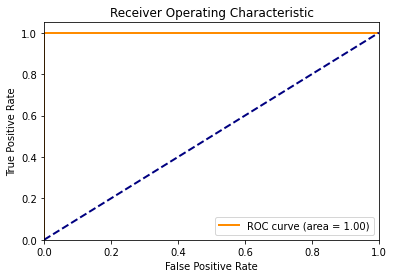

In [ ]:
# Importar las librerías necesarias
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Obtener las predicciones y los valores reales
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Obtener las probabilidades de la clase positiva
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [ ]:
import pickle

# Exportar el modelo a un archivo
with open('random_forest_model.pkl', 'wb') as file:
    pickle.dump(model, file)